# Investigating Customer Churn in Banking: A Machine Learning Approach
## Reproduction complète — Singh et al. (2024) — Data Science and Management
**DOI: 10.1016/j.dsm.2023.09.002**

---
### Plan du notebook
1. Chargement et description du dataset
2. Analyse exploratoire (EDA) — Figures 2, 3, 4, 5, 6, 7
3. Préparation des données + Feature Engineering
4. Modèles SANS SMOTE — Table 4
5. Modèles AVEC SMOTE — Table 5
6. Résultats comparatifs finaux

---
## Étape 0 — Installation des bibliothèques

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [2]:
!pip install xgboost imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.pipeline            import Pipeline
from sklearn.linear_model        import LogisticRegression
from sklearn.svm                 import SVC
from sklearn.ensemble            import RandomForestClassifier
from xgboost                     import XGBClassifier
from sklearn.metrics             import (accuracy_score, confusion_matrix,
                                          classification_report, roc_auc_score,
                                          roc_curve, f1_score, RocCurveDisplay)
from imblearn.over_sampling      import SMOTE

# Style global des graphiques
plt.rcParams['figure.dpi']     = 120
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

print('Toutes les bibliothèques importées avec succès.')

Toutes les bibliothèques importées avec succès.


---
## Section 2.1 — Description du dataset
*(Table 3 du papier)*

In [3]:
# Chargement du dataset
df = pd.read_csv('Churn_Modelling.csv')

print('Shape :', df.shape)
print()
print(df.head())
print()

# Table 3 du papier — Variables, Null count, Unique count
table3 = pd.DataFrame({
    'Variables'   : df.columns,
    'Null count'  : df.isnull().sum().values,
    'Unique count': df.nunique().values
})
print('=== Table 3 — Variables, null count, and unique count ===')
print(table3.to_string(index=False))

Shape : (10000, 14)

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63   

---
## Section 2.2(a) — Figure 2 : Customer Churn Distribution (Pie Chart)

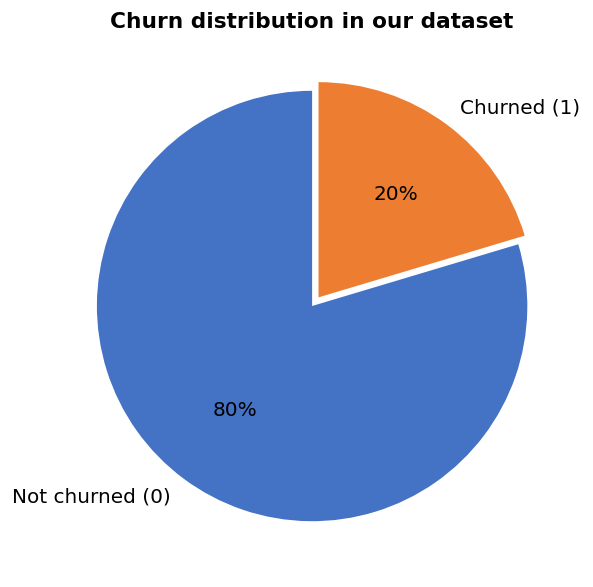

Not churned : 7963 (80%)
Churned     : 2037 (20%)


In [4]:
# Figure 2 du papier — Pie chart distribution churn
churn_counts = df['Exited'].value_counts()
labels = ['Not churned (0)', 'Churned (1)']
colors = ['#4472C4', '#ED7D31']
explode = (0, 0.05)

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    churn_counts,
    labels=labels,
    autopct='%1.0f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12}
)
ax.set_title('Churn distribution in our dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Not churned : {churn_counts[0]} ({churn_counts[0]/len(df)*100:.0f}%)')
print(f'Churned     : {churn_counts[1]} ({churn_counts[1]/len(df)*100:.0f}%)')

---
## Section 2.2(b) — Figure 3 : Gender, Credit Card, Active Member, Country vs Churn
*(Histogrammes — 4 sous-graphiques)*

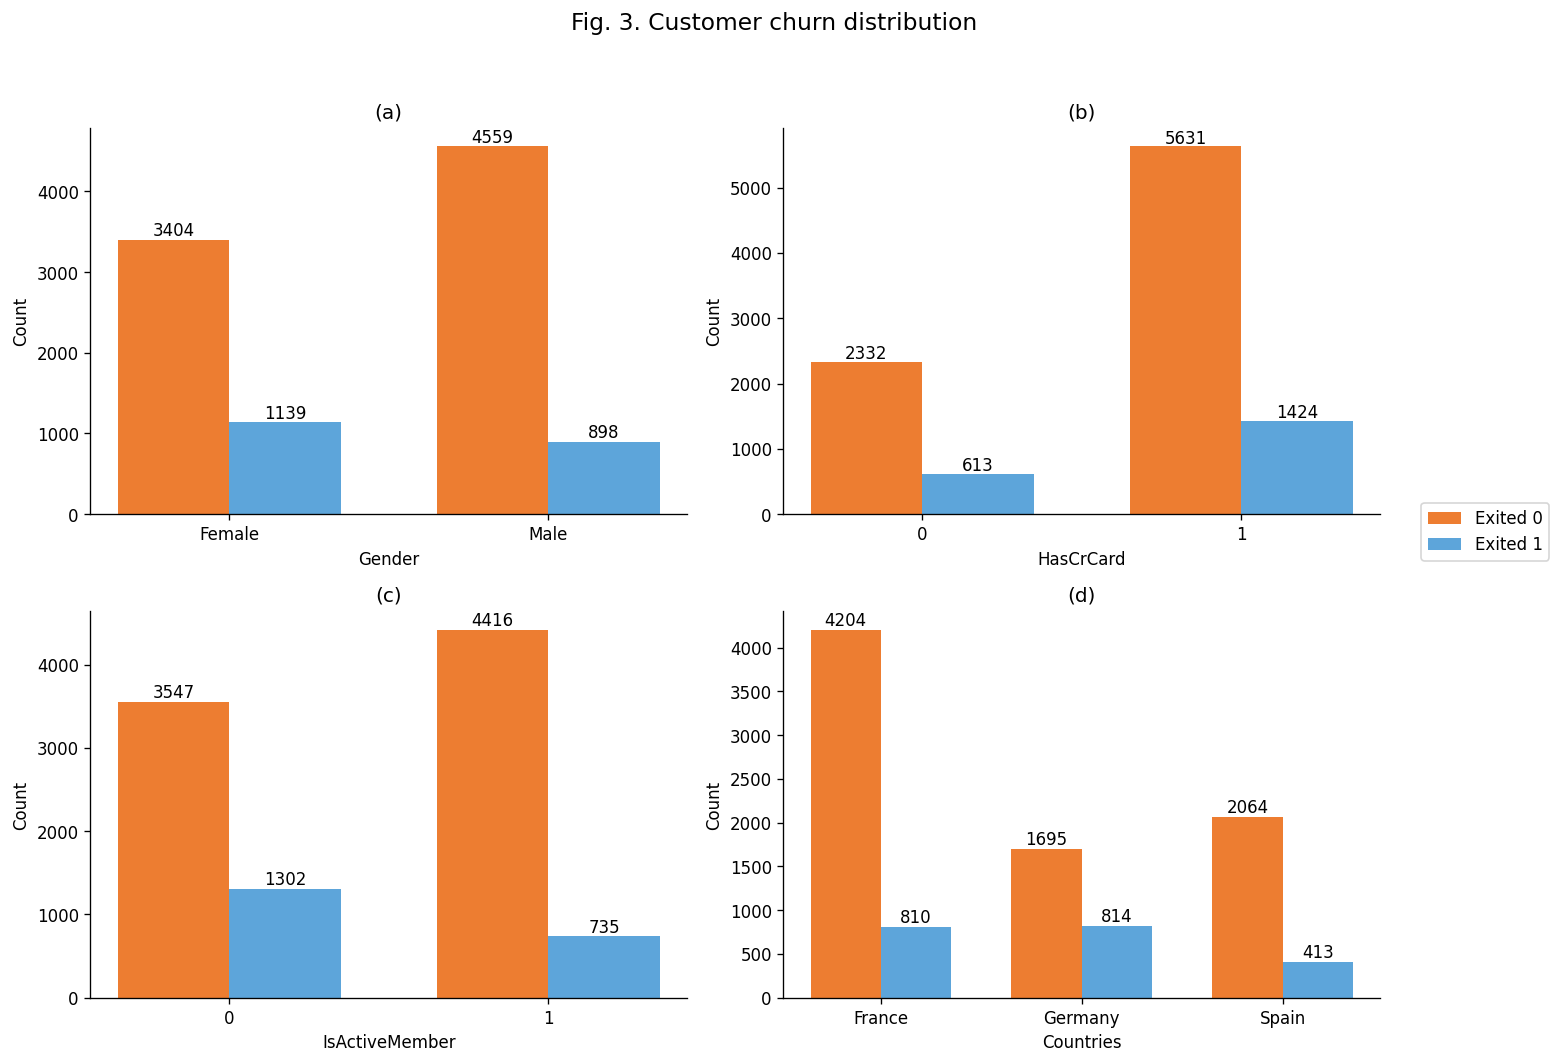

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Couleurs du papier
palette = {0: '#ED7D31', 1: '#5DA5DA'}

bar_width = 0.35

# ================= (a) Gender =================
gender_churn = df.groupby(['Gender', 'Exited']).size().unstack()

x = np.arange(len(gender_churn.index))

axes[0,0].bar(x - bar_width/2, gender_churn[0], width=bar_width, color=palette[0], label='0')
axes[0,0].bar(x + bar_width/2, gender_churn[1], width=bar_width, color=palette[1], label='1')

axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(gender_churn.index)

for i in range(len(x)):
    axes[0,0].text(x[i] - bar_width/2, gender_churn[0][i] + 50, int(gender_churn[0][i]), ha='center')
    axes[0,0].text(x[i] + bar_width/2, gender_churn[1][i] + 50, int(gender_churn[1][i]), ha='center')

axes[0,0].set_title('(a)')
axes[0,0].set_xlabel('Gender')
axes[0,0].set_ylabel('Count')


# ================= (b) HasCrCard =================
cc_churn = df.groupby(['HasCrCard', 'Exited']).size().unstack()
x = np.arange(len(cc_churn.index))

axes[0,1].bar(x - bar_width/2, cc_churn[0], width=bar_width, color=palette[0])
axes[0,1].bar(x + bar_width/2, cc_churn[1], width=bar_width, color=palette[1])

axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(cc_churn.index)

for i in range(len(x)):
    axes[0,1].text(x[i] - bar_width/2, cc_churn[0][i] + 50, int(cc_churn[0][i]), ha='center')
    axes[0,1].text(x[i] + bar_width/2, cc_churn[1][i] + 50, int(cc_churn[1][i]), ha='center')

axes[0,1].set_title('(b)')
axes[0,1].set_xlabel('HasCrCard')
axes[0,1].set_ylabel('Count')


# ================= (c) IsActiveMember =================
act_churn = df.groupby(['IsActiveMember', 'Exited']).size().unstack()
x = np.arange(len(act_churn.index))

axes[1,0].bar(x - bar_width/2, act_churn[0], width=bar_width, color=palette[0])
axes[1,0].bar(x + bar_width/2, act_churn[1], width=bar_width, color=palette[1])

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(act_churn.index)

for i in range(len(x)):
    axes[1,0].text(x[i] - bar_width/2, act_churn[0][i] + 50, int(act_churn[0][i]), ha='center')
    axes[1,0].text(x[i] + bar_width/2, act_churn[1][i] + 50, int(act_churn[1][i]), ha='center')

axes[1,0].set_title('(c)')
axes[1,0].set_xlabel('IsActiveMember')
axes[1,0].set_ylabel('Count')


# ================= (d) Geography =================
geo_churn = df.groupby(['Geography', 'Exited']).size().unstack()
x = np.arange(len(geo_churn.index))

axes[1,1].bar(x - bar_width/2, geo_churn[0], width=bar_width, color=palette[0])
axes[1,1].bar(x + bar_width/2, geo_churn[1], width=bar_width, color=palette[1])

axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(geo_churn.index)

for i in range(len(x)):
    axes[1,1].text(x[i] - bar_width/2, geo_churn[0][i] + 50, int(geo_churn[0][i]), ha='center')
    axes[1,1].text(x[i] + bar_width/2, geo_churn[1][i] + 50, int(geo_churn[1][i]), ha='center')

axes[1,1].set_title('(d)')
axes[1,1].set_xlabel('Countries')
axes[1,1].set_ylabel('Count')


# ================= Global =================
fig.legend(['Exited 0', 'Exited 1'], loc='center right')
plt.suptitle('Fig. 3. Customer churn distribution', fontsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

---
## Section 2.2(c) — Figure 4 : Density Plots (Balance, Products, CreditScore, Tenure)

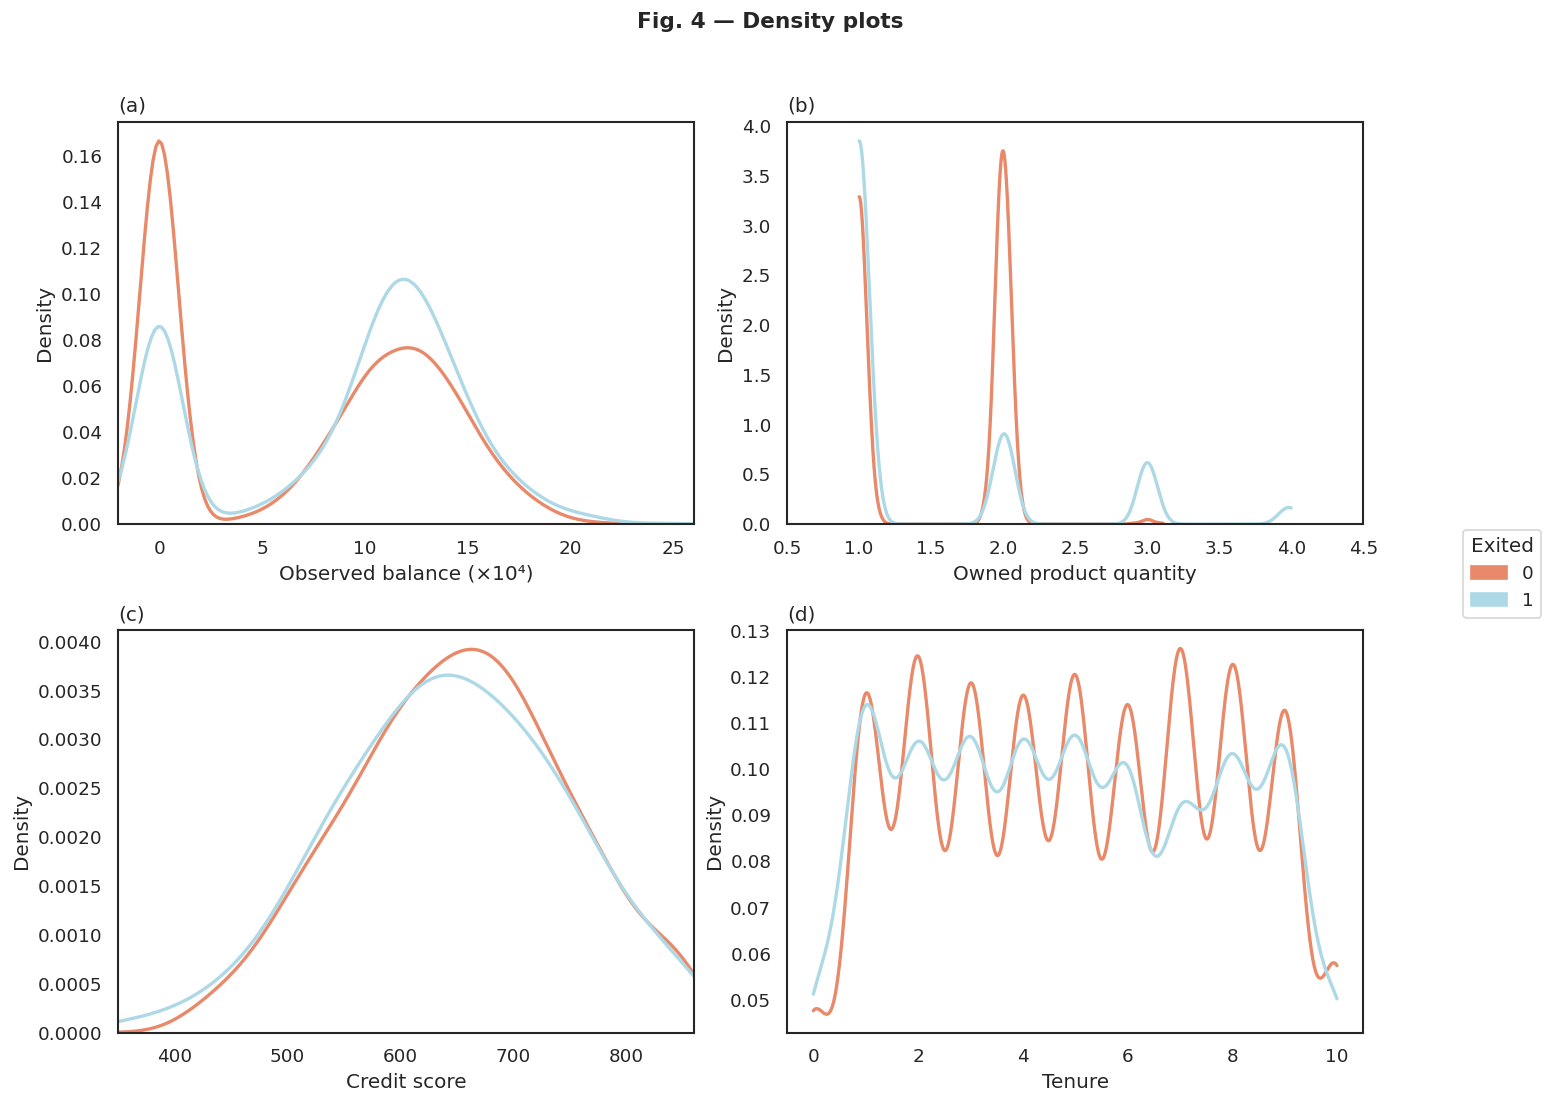

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# reproductibilité (TRÈS IMPORTANT)
np.random.seed(42)

# style type papier
sns.set(style="white", font_scale=1.0)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# séparation
churn0 = df[df['Exited'] == 0]
churn1 = df[df['Exited'] == 1]

# couleurs
c0 = '#E8896A'   # Exited 0
c1 = '#ADD8E6'   # Exited 1


# =========================
# fonction jitter (clé pour variables discrètes)
# =========================
def jitter(x, scale):
    return x + np.random.normal(0, scale, size=len(x))


# =========================
# (a) Balance
# =========================
balance0 = churn0['Balance'] / 10000
balance1 = churn1['Balance'] / 10000

sns.kdeplot(balance0, ax=axes[0,0],
            color=c0, bw_adjust=0.9,
            linewidth=2, common_norm=True)

sns.kdeplot(balance1, ax=axes[0,0],
            color=c1, bw_adjust=0.9,
            linewidth=2, common_norm=True)

axes[0,0].set_title('(a)', loc='left')
axes[0,0].set_xlabel('Observed balance (×10⁴)')
axes[0,0].set_ylabel('Density')
axes[0,0].set_xlim(-2, 26)


# =========================
# (b) NumOfProducts (KDE + jitter)
# =========================
sns.kdeplot(jitter(churn0['NumOfProducts'], 0.05),
            ax=axes[0,1],
            color=c0,
            bw_adjust=0.3,
            cut=0,
            clip=(1,4),
            gridsize=1000,
            linewidth=2,
            common_norm=True)

sns.kdeplot(jitter(churn1['NumOfProducts'], 0.05),
            ax=axes[0,1],
            color=c1,
            bw_adjust=0.3,
            cut=0,
            clip=(1,4),
            gridsize=1000,
            linewidth=2,
            common_norm=True)

axes[0,1].set_title('(b)', loc='left')
axes[0,1].set_xlabel('Owned product quantity')
axes[0,1].set_ylabel('Density')
axes[0,1].set_xlim(0.5, 4.5)


# =========================
# (c) CreditScore
# =========================
sns.kdeplot(churn0['CreditScore'], ax=axes[1,0],
            color=c0, bw_adjust=1.6,
            linewidth=2, common_norm=True)

sns.kdeplot(churn1['CreditScore'], ax=axes[1,0],
            color=c1, bw_adjust=1.6,
            linewidth=2, common_norm=True)

axes[1,0].set_title('(c)', loc='left')
axes[1,0].set_xlabel('Credit score')
axes[1,0].set_ylabel('Density')
axes[1,0].set_xlim(350, 860)


# =========================
# (d) Tenure (KDE + jitter)
# =========================
sns.kdeplot(jitter(churn0['Tenure'], 0.2),
            ax=axes[1,1],
            color=c0,
            bw_adjust=0.6,
            cut=0,
            clip=(0,10),
            gridsize=1000,
            linewidth=2,
            common_norm=True)

sns.kdeplot(jitter(churn1['Tenure'], 0.2),
            ax=axes[1,1],
            color=c1,
            bw_adjust=0.6,
            cut=0,
            clip=(0,10),
            gridsize=1000,
            linewidth=2,
            common_norm=True)

axes[1,1].set_title('(d)', loc='left')
axes[1,1].set_xlabel('Tenure')
axes[1,1].set_ylabel('Density')
axes[1,1].set_xlim(-0.5, 10.5)


# =========================
# légende (comme papier)
# =========================
legend_elements = [
    Patch(facecolor=c0, edgecolor=c0, label='0'),
    Patch(facecolor=c1, edgecolor=c1, label='1'),
]

fig.legend(handles=legend_elements,
           title='Exited',
           loc='center right',
           bbox_to_anchor=(1.0, 0.5),
           frameon=True)


# =========================
# mise en page finale
# =========================
plt.suptitle('Fig. 4 — Density plots',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(right=0.88)

plt.show()

---
## Section 2.2(c) — Figure 5 : Distribution of customers based on CreditScore and Age
*(Scatter plot — comme dans le papier)*

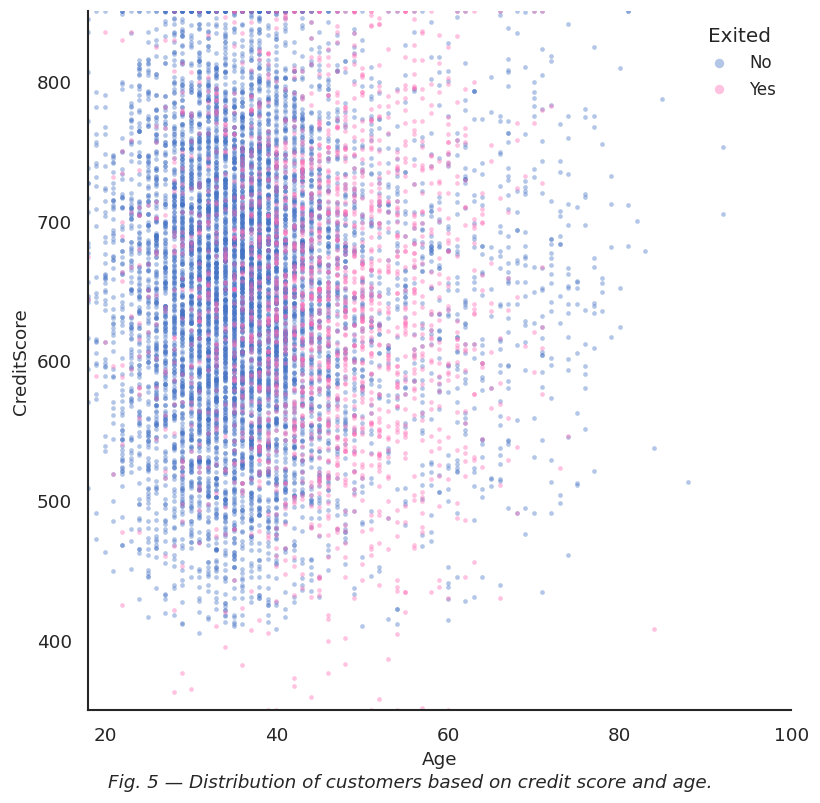

In [16]:
# Figure 5 du papier — Distribution of customers based on credit score and age
fig, ax = plt.subplots(figsize=(7, 7))

np.random.seed(42)

for exited_val, color, label in [(0, '#4472C4', 'No'), (1, '#FF69B4', 'Yes')]:
    subset = df[df['Exited'] == exited_val]
    ax.scatter(subset['Age'], subset['CreditScore'],
               c=color, alpha=0.4, s=8,
               label=label, linewidths=0)

ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('CreditScore', fontsize=11)
ax.set_xlim(18, 100)
ax.set_ylim(350, 850)
ax.set_xticks([20, 40, 60, 80, 100])
ax.set_yticks([400, 500, 600, 700, 800])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title='Exited', loc='upper right',
          markerscale=2, fontsize=10, frameon=False)

plt.suptitle('Fig. 5 — Distribution of customers based on credit score and age.',
             fontsize=11, y=0.02, fontstyle='italic')
plt.tight_layout()
plt.show()

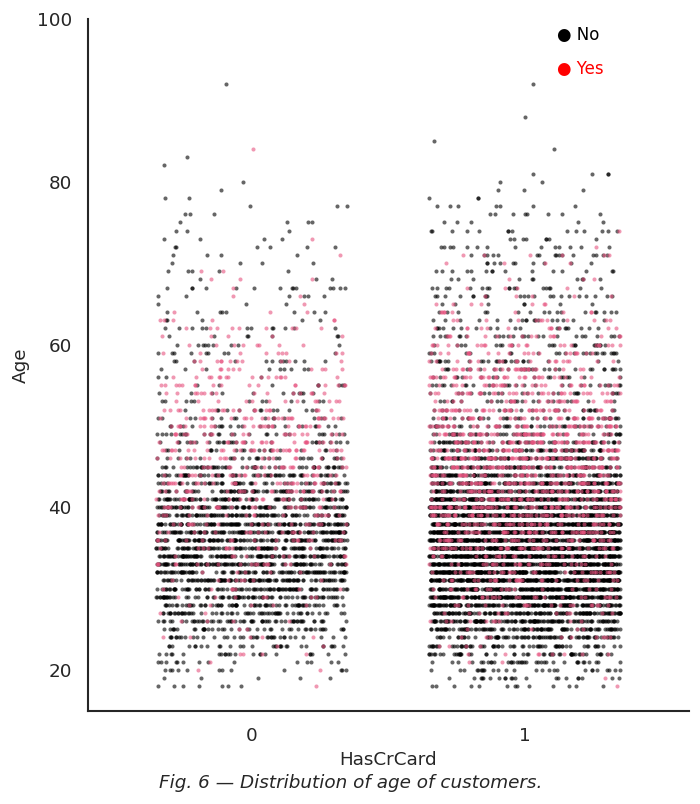

In [18]:
# Figure 6 du papier — Distribution of age of customers (Jitter/Swarm plot)
import numpy as np

fig, ax = plt.subplots(figsize=(6, 7))

# Couleurs exactes du papier : No (Exited=0) = noir, Yes (Exited=1) = rose
colors = {0: 'black', 1: '#E75480'}  # rose foncé comme dans le papier

# Jitter horizontal pour séparer les points (sinon superposés)
np.random.seed(42)

for exited_val, color, label in [(0, 'black', 'No'), (1, '#E75480', 'Yes')]:
    subset = df[df['Exited'] == exited_val]
    # Jitter sur l'axe X autour de 0 et 1
    x_jitter = subset['HasCrCard'] + np.random.uniform(-0.35, 0.35, size=len(subset))
    ax.scatter(x_jitter, subset['Age'],
               c=color, s=6, alpha=0.6,
               label=label, linewidths=0)

# Axes exactement comme le papier
ax.set_xlabel('HasCrCard', fontsize=11)
ax.set_ylabel('Age', fontsize=11)
ax.set_title('')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(15, 100)
ax.set_yticks([20, 40, 60, 80, 100])

# Supprimer les bordures haut et droite comme dans le papier
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Légende en haut à droite avec petits cercles
legend = ax.legend(title='', loc='upper right',
                   markerscale=2, fontsize=10,
                   frameon=False)
# Ajouter les labels No / Yes manuellement
for handle, label in zip(legend.legend_handles, ['No', 'Yes']):
    handle.set_sizes([40])

ax.annotate('● No',  xy=(0.78, 0.97), xycoords='axes fraction', fontsize=10,
            color='black')
ax.annotate('● Yes', xy=(0.78, 0.92), xycoords='axes fraction', fontsize=10,
            color='red')
ax.get_legend().remove()

plt.suptitle('Fig. 6 — Distribution of age of customers.',
             fontsize=11, y=0.02, fontstyle='italic')
plt.tight_layout()
plt.show()

---
## Section 2.2 — Figure 6 : Box plot — Age distribution
*("older customers above 40 are more likely to churn")*

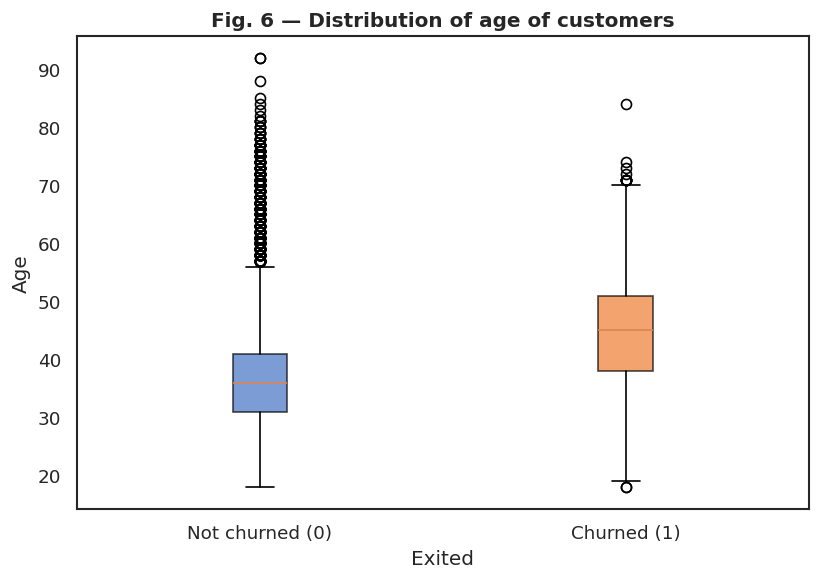

Âge médian — Not churned : 36.0
Âge médian — Churned     : 45.0


In [12]:
# Figure 6 du papier — Box plot de l'âge par classe
fig, ax = plt.subplots(figsize=(7, 5))

data_to_plot = [df[df['Exited']==0]['Age'], df[df['Exited']==1]['Age']]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['Not churned (0)', 'Churned (1)'])

colors_box = ['#4472C4', '#ED7D31']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Fig. 6 — Distribution of age of customers', fontsize=12, fontweight='bold')
ax.set_ylabel('Age')
ax.set_xlabel('Exited')
plt.tight_layout()
plt.show()

print('Âge médian — Not churned :', df[df['Exited']==0]['Age'].median())
print('Âge médian — Churned     :', df[df['Exited']==1]['Age'].median())

---
## Section 2.2(d) — Figure 7 : Correlation Matrix

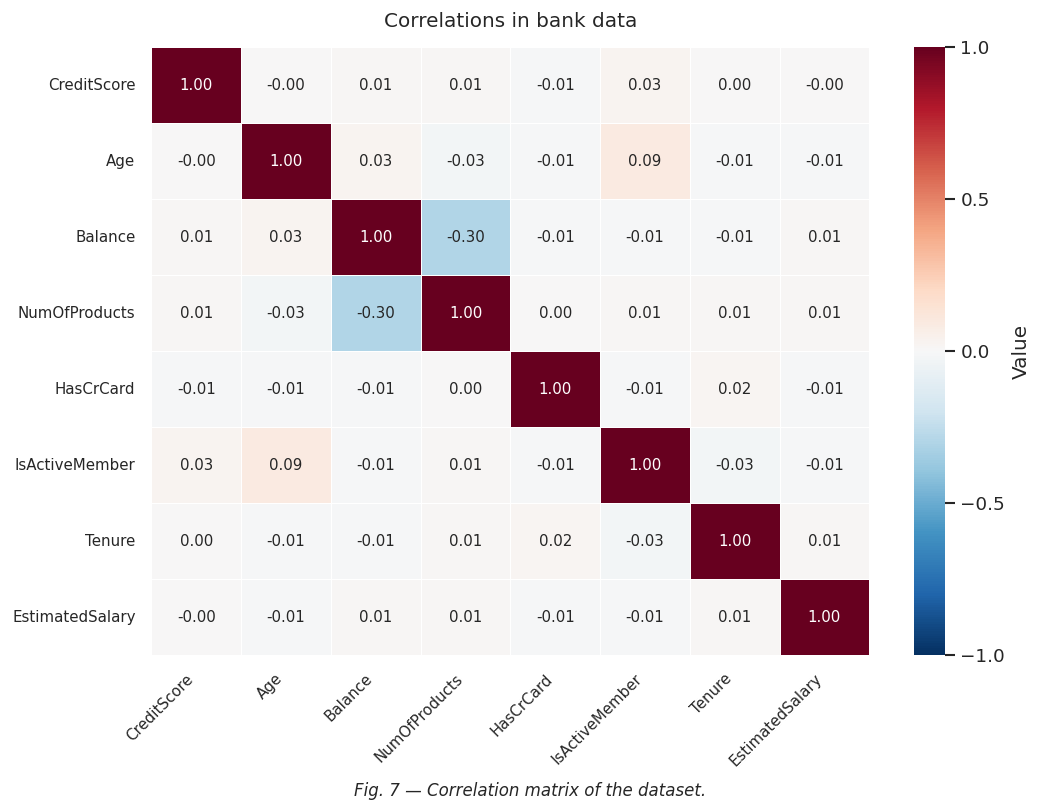

In [19]:
# Figure 7 du papier — Matrice de corrélation
df_corr = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender', 'Exited'])

corr_matrix = df_corr.corr().round(2)

# Réordonner les colonnes/lignes exactement comme dans le papier
order = ['CreditScore', 'Age', 'Balance', 'NumOfProducts',
         'HasCrCard', 'IsActiveMember', 'Tenure', 'EstimatedSalary']
corr_matrix = corr_matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Value',
                      'ticks': [1.0, 0.5, 0.0, -0.5, -1.0]})

ax.set_title('Correlations in bank data', fontsize=12, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Fig. 7 — Correlation matrix of the dataset.',
             fontsize=10, y=0.01, fontstyle='italic')
plt.tight_layout()
plt.show()

---
## Section 3.2 — Préparation des données
### Suppression colonnes inutiles + Feature Engineering
*(Le papier crée 3 nouvelles variables : TenureByAge, BalanceSalaryRatio, CreditScoreGivenAge)*

In [20]:
# Copie du dataset original
df_model = df.copy()

# Suppression des colonnes non pertinentes
# Le papier dit : 'RowNumber, CustomerID, and Surname were removed'
df_model = df_model.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# -------------------------------------------------------
# Feature Engineering — 3 nouvelles variables du papier
# 'three new variables were created: TenureByAge,
#  BalanceSalaryRatio, CreditScoreGivenAge'
# -------------------------------------------------------
df_model['TenureByAge']         = df_model['Tenure'] / (df_model['Age'] + 1)
df_model['BalanceSalaryRatio']  = df_model['Balance'] / (df_model['EstimatedSalary'] + 1)
df_model['CreditScoreGivenAge'] = df_model['CreditScore'] / (df_model['Age'] + 1)

print('Nouvelles features créées :')
print(df_model[['TenureByAge', 'BalanceSalaryRatio', 'CreditScoreGivenAge']].describe().round(3))
print()
print('Shape après feature engineering :', df_model.shape)

Nouvelles features créées :
       TenureByAge  BalanceSalaryRatio  CreditScoreGivenAge
count    10000.000           10000.000            10000.000
mean         0.134               3.790               17.366
std          0.086             100.056                5.109
min          0.000               0.000                4.800
25%          0.062               0.000               13.769
50%          0.125               0.747               16.824
75%          0.194               1.514               20.333
max          0.526            9770.883               44.421

Shape après feature engineering : (10000, 14)


In [21]:
# Encodage des variables catégorielles
le = LabelEncoder()
df_model['Gender']    = le.fit_transform(df_model['Gender'])     # Female=0, Male=1
df_model['Geography'] = le.fit_transform(df_model['Geography'])  # France=0, Germany=1, Spain=2

# Séparation features / cible
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

print('Features finales :', X.columns.tolist())
print('Nombre de features :', X.shape[1])

Features finales : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'TenureByAge', 'BalanceSalaryRatio', 'CreditScoreGivenAge']
Nombre de features : 13


---
## Section 3.2 — Division Train/Test (20%–80%)
*(Le papier utilise 20-80 split comme mentionné dans la Figure 12)*

In [22]:
# Division train/test — 80% train, 20% test (comme dans le papier)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)')

Train : 8000 samples (80%)
Test  : 2000  samples (20%)


---
## Section 3.2 — Fonction d'évaluation
*(Calcule toutes les métriques des Tables 4 et 5 : Accuracy, Sensitivity, Specificity, AUC, F1)*

In [23]:
def compute_metrics(model, X_te, y_te, model_name):
    """Calcule toutes les métriques du papier : Table 4 et Table 5."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    cm    = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN)          # = Recall
    specificity = TN / (TN + FP)
    auc         = roc_auc_score(y_te, y_prob)
    f1          = f1_score(y_te, y_pred)

    print(f'\n=== {model_name} ===')
    print(f'  Accuracy    : {accuracy:.3f}')
    print(f'  Sensitivity : {sensitivity:.3f}')
    print(f'  Specificity : {specificity:.3f}')
    print(f'  AUC         : {auc:.3f}')
    print(f'  F1 score    : {f1:.3f}')
    print(f'  Confusion Matrix : TN={TN} FP={FP} FN={FN} TP={TP}')

    return {
        'Model'      : model_name,
        'Accuracy'   : round(accuracy, 3),
        'Sensitivity': round(sensitivity, 3),
        'Specificity': round(specificity, 3),
        'AUC'        : round(auc, 3),
        'F1 score'   : round(f1, 3)
    }

print('Fonction compute_metrics définie.')

Fonction compute_metrics définie.


---
## Section 3.2 — Pipelines des 4 modèles
*(Le papier construit des pipelines : Normalize → Model, avec Grid Search)*

In [24]:
# Construction des 4 pipelines (Normalize + Model) comme dans le papier
# 'We orchestrated model training by constructing a two-step workflow pipeline:
#  Normalize the features → Instantiate the model'

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(probability=True, random_state=42))
])

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  XGBClassifier(use_label_encoder=False,
                              eval_metric='logloss',
                              random_state=42))
])

pipelines = {
    'Logistic regression': pipe_lr,
    'Support vector machine': pipe_svm,
    'Random forest': pipe_rf,
    'XGBoost': pipe_xgb
}

print('4 pipelines créés.')

4 pipelines créés.


---
## Section 4 — Table 4 : Résultats SANS SMOTE
*(Dataset déséquilibré original)*

In [25]:
print('=== ENTRAÎNEMENT SANS SMOTE (Table 4) ===')
print(f'Distribution y_train : {dict(y_train.value_counts())}')
print()

results_no_smote = []
trained_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    metrics = compute_metrics(pipe, X_test, y_test, name)
    results_no_smote.append(metrics)

=== ENTRAÎNEMENT SANS SMOTE (Table 4) ===
Distribution y_train : {0: np.int64(6356), 1: np.int64(1644)}


=== Logistic regression ===
  Accuracy    : 0.822
  Sensitivity : 0.193
  Specificity : 0.976
  AUC         : 0.772
  F1 score    : 0.299
  Confusion Matrix : TN=1568 FP=39 FN=317 TP=76

=== Support vector machine ===
  Accuracy    : 0.857
  Sensitivity : 0.366
  Specificity : 0.977
  AUC         : 0.823
  F1 score    : 0.502
  Confusion Matrix : TN=1570 FP=37 FN=249 TP=144

=== Random forest ===
  Accuracy    : 0.870
  Sensitivity : 0.455
  Specificity : 0.971
  AUC         : 0.852
  F1 score    : 0.578
  Confusion Matrix : TN=1560 FP=47 FN=214 TP=179

=== XGBoost ===
  Accuracy    : 0.858
  Sensitivity : 0.491
  Specificity : 0.948
  AUC         : 0.846
  F1 score    : 0.576
  Confusion Matrix : TN=1523 FP=84 FN=200 TP=193


In [26]:
# Table 4 du papier — Affichage formaté
table4 = pd.DataFrame(results_no_smote).set_index('Model')
print('\n=== TABLE 4 — Evaluation metrics (WITHOUT SMOTE) ===')
print(table4.to_string())
print()
print('Résultats attendus du papier :')
print('  LR  : Acc=0.793, Spec=0.961, Sens=0.173, AUC=0.763, F1=0.263')
print('  SVM : Acc=0.802, Spec=0.987, Sens=0.119, AUC=0.750, F1=0.205')
print('  RF  : Acc=0.844, Spec=0.977, Sens=0.353, AUC=0.831, F1=0.491')
print('  XGB : Acc=0.852, Spec=0.963, Sens=0.440, AUC=0.842, F1=0.559')


=== TABLE 4 — Evaluation metrics (WITHOUT SMOTE) ===
                        Accuracy  Sensitivity  Specificity    AUC  F1 score
Model                                                                      
Logistic regression        0.822        0.193        0.976  0.772     0.299
Support vector machine     0.857        0.366        0.977  0.823     0.502
Random forest              0.870        0.455        0.971  0.852     0.578
XGBoost                    0.858        0.491        0.948  0.846     0.576

Résultats attendus du papier :
  LR  : Acc=0.793, Spec=0.961, Sens=0.173, AUC=0.763, F1=0.263
  SVM : Acc=0.802, Spec=0.987, Sens=0.119, AUC=0.750, F1=0.205
  RF  : Acc=0.844, Spec=0.977, Sens=0.353, AUC=0.831, F1=0.491
  XGB : Acc=0.852, Spec=0.963, Sens=0.440, AUC=0.842, F1=0.559


---
## Application de SMOTE — Table 5 : Résultats AVEC SMOTE
*(Le papier dit : 'We used SMOTE to address the imbalance')*

In [29]:
# Application de SMOTE sur le train set uniquement
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('=== Distribution AVANT SMOTE ===')
print(dict(y_train.value_counts()))
print()
print('=== Distribution APRÈS SMOTE ===')
print(dict(pd.Series(y_train_sm).value_counts()))
print(f'\nTrain size après SMOTE : {len(X_train_sm)}')

=== Distribution AVANT SMOTE ===
{0: np.int64(6356), 1: np.int64(1644)}

=== Distribution APRÈS SMOTE ===
{0: np.int64(6356), 1: np.int64(6356)}

Train size après SMOTE : 12712


In [30]:
print('=== ENTRAÎNEMENT AVEC SMOTE (Table 5) ===')
print()

results_smote = []
trained_models_sm = {}

for name, pipe in pipelines.items():
    # Créer une nouvelle instance du pipeline
    import copy
    pipe_sm = copy.deepcopy(pipe)
    pipe_sm.fit(X_train_sm, y_train_sm)
    trained_models_sm[name] = pipe_sm
    metrics = compute_metrics(pipe_sm, X_test, y_test, name)
    results_smote.append(metrics)

=== ENTRAÎNEMENT AVEC SMOTE (Table 5) ===


=== Logistic regression ===
  Accuracy    : 0.739
  Sensitivity : 0.560
  Specificity : 0.782
  AUC         : 0.741
  F1 score    : 0.457
  Confusion Matrix : TN=1257 FP=350 FN=173 TP=220

=== Support vector machine ===
  Accuracy    : 0.822
  Sensitivity : 0.628
  Specificity : 0.869
  AUC         : 0.836
  F1 score    : 0.580
  Confusion Matrix : TN=1396 FP=211 FN=146 TP=247

=== Random forest ===
  Accuracy    : 0.829
  Sensitivity : 0.641
  Specificity : 0.875
  AUC         : 0.833
  F1 score    : 0.596
  Confusion Matrix : TN=1406 FP=201 FN=141 TP=252

=== XGBoost ===
  Accuracy    : 0.827
  Sensitivity : 0.595
  Specificity : 0.884
  AUC         : 0.845
  F1 score    : 0.575
  Confusion Matrix : TN=1420 FP=187 FN=159 TP=234


In [31]:
# Table 5 du papier — Affichage formaté
table5 = pd.DataFrame(results_smote).set_index('Model')
print('\n=== TABLE 5 — Evaluation metrics (WITH SMOTE) ===')
print(table5.to_string())
print()
print('Résultats attendus du papier :')
print('  LR  : Acc=0.691, Spec=0.685, Sens=0.714, AUC=0.767, F1=0.497')
print('  SVM : Acc=0.719, Spec=0.731, Sens=0.672, AUC=0.765, F1=0.505')
print('  RF  : Acc=0.783, Spec=0.807, Sens=0.693, AUC=0.831, F1=0.577')
print('  XGB : Acc=0.839, Spec=0.903, Sens=0.601, AUC=0.847, F1=0.613')


=== TABLE 5 — Evaluation metrics (WITH SMOTE) ===
                        Accuracy  Sensitivity  Specificity    AUC  F1 score
Model                                                                      
Logistic regression        0.738        0.560        0.782  0.741     0.457
Support vector machine     0.822        0.628        0.869  0.836     0.580
Random forest              0.829        0.641        0.875  0.833     0.596
XGBoost                    0.827        0.595        0.884  0.845     0.575

Résultats attendus du papier :
  LR  : Acc=0.691, Spec=0.685, Sens=0.714, AUC=0.767, F1=0.497
  SVM : Acc=0.719, Spec=0.731, Sens=0.672, AUC=0.765, F1=0.505
  RF  : Acc=0.783, Spec=0.807, Sens=0.693, AUC=0.831, F1=0.577
  XGB : Acc=0.839, Spec=0.903, Sens=0.601, AUC=0.847, F1=0.613


---
## Visualisation finale — Comparaison Tables 4 & 5
*(Reproduit les barres comparatives du papier)*

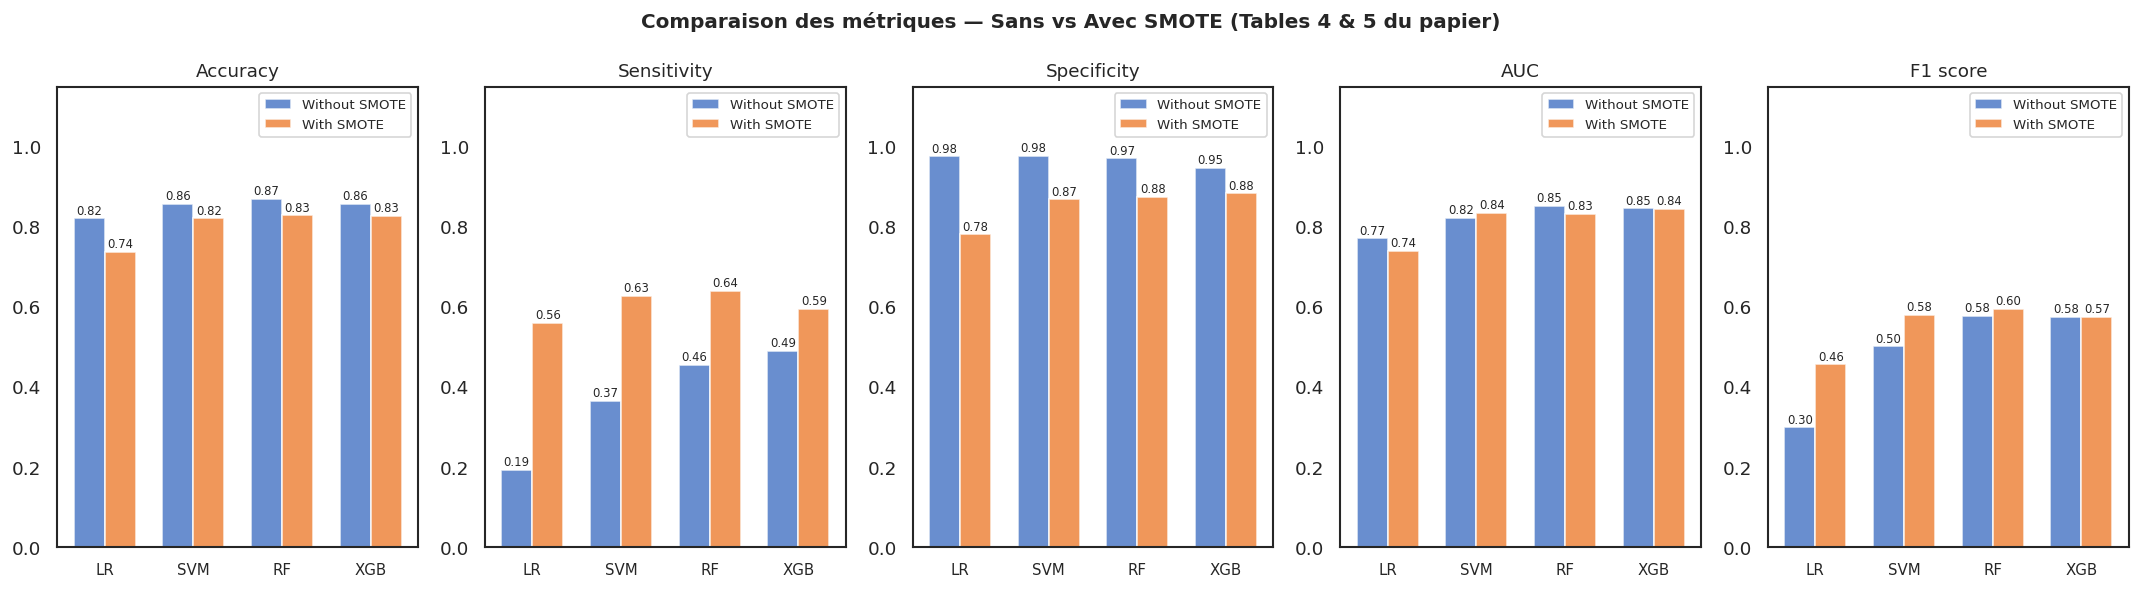

In [32]:
# Comparaison visuelle Table 4 vs Table 5
metrics_list = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC', 'F1 score']
model_names  = ['Logistic regression', 'Support vector machine', 'Random forest', 'XGBoost']
short_names  = ['LR', 'SVM', 'RF', 'XGB']

fig, axes = plt.subplots(1, len(metrics_list), figsize=(18, 5))
x = np.arange(len(model_names))
width = 0.35

for i, metric in enumerate(metrics_list):
    vals_no  = [table4.loc[m, metric] for m in model_names]
    vals_sm  = [table5.loc[m, metric] for m in model_names]

    axes[i].bar(x - width/2, vals_no, width, label='Without SMOTE', color='#4472C4', alpha=0.8)
    axes[i].bar(x + width/2, vals_sm, width, label='With SMOTE',    color='#ED7D31', alpha=0.8)
    axes[i].set_title(metric, fontsize=11)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(short_names, fontsize=9)
    axes[i].set_ylim(0, 1.15)
    axes[i].legend(fontsize=8)
    for j, (v1, v2) in enumerate(zip(vals_no, vals_sm)):
        axes[i].text(j - width/2, v1 + 0.01, f'{v1:.2f}', ha='center', fontsize=7)
        axes[i].text(j + width/2, v2 + 0.01, f'{v2:.2f}', ha='center', fontsize=7)

plt.suptitle('Comparaison des métriques — Sans vs Avec SMOTE (Tables 4 & 5 du papier)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Courbes ROC — 4 modèles AVEC SMOTE (Figure 12 du papier)

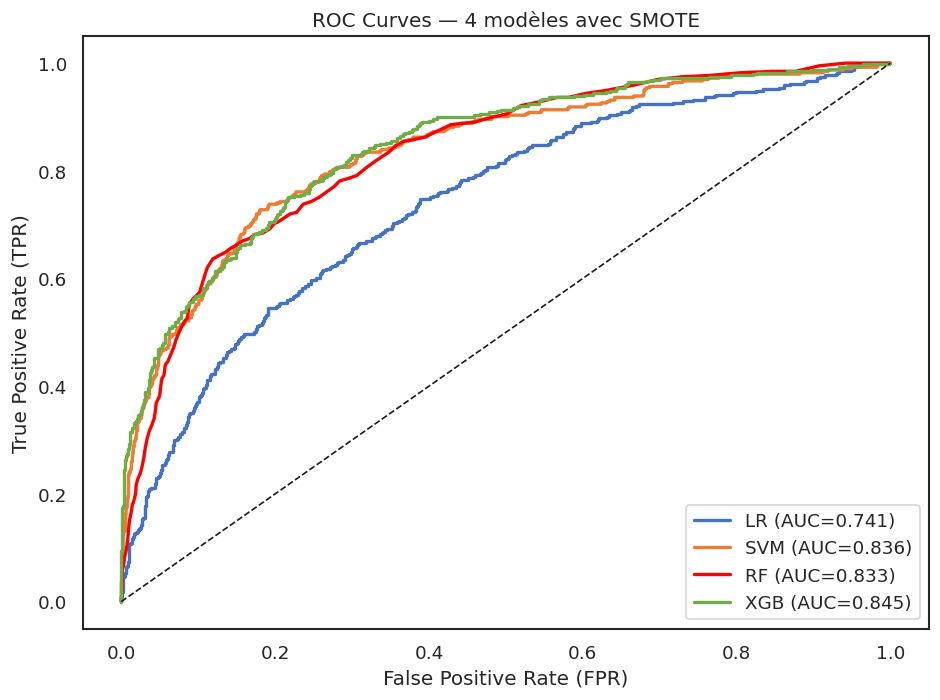

In [33]:
# Courbes ROC des 4 modèles avec SMOTE
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#4472C4', '#ED7D31', '#FF0000', '#70AD47']

for (name, pipe_sm), color in zip(trained_models_sm.items(), colors_roc):
    y_prob = pipe_sm.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    short = {'Logistic regression':'LR','Support vector machine':'SVM',
             'Random forest':'RF','XGBoost':'XGB'}[name]
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{short} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curves — 4 modèles avec SMOTE')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Random Forest — Feature Importance AVEC SMOTE (Figure 12 du papier)

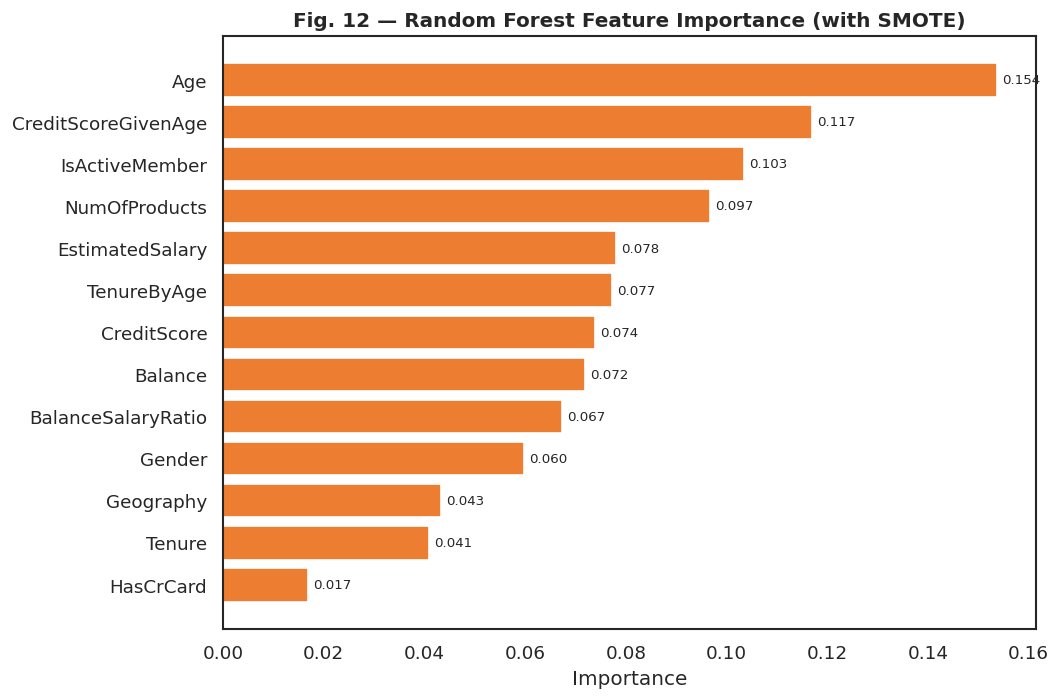

In [34]:
# Feature importance RF avec SMOTE — comme dans la Figure 12 du papier
rf_sm = trained_models_sm['Random forest']
fi_sm = pd.Series(
    rf_sm.named_steps['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_sm.index, fi_sm.values, color='#ED7D31')
ax.set_title('Fig. 12 — Random Forest Feature Importance (with SMOTE)', fontweight='bold')
ax.set_xlabel('Importance')
for i, (val, name) in enumerate(zip(fi_sm.values, fi_sm.index)):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Résumé final — Tables 4 & 5 côte à côte

In [35]:
print('='*65)
print('TABLE 4 — Evaluation metrics (WITHOUT SMOTE)')
print('='*65)
print(table4.to_string())
print()
print('='*65)
print('TABLE 5 — Evaluation metrics (WITH SMOTE)')
print('='*65)
print(table5.to_string())
print()
print('=== CONCLUSION DU PAPIER ===')
print()
print('Sans SMOTE : XGBoost meilleur en accuracy (0.852)')
print('Avec SMOTE : XGBoost meilleur en accuracy (0.839)')
print('           : LR meilleur en sensitivity (0.714)')
print('           : Random Forest meilleur OVERALL (accuracy + sensitivity)')
print()
print('Facteurs clés identifiés :')
print('  - Les clients allemands ont +0.93 odds de churn vs France/Espagne')
print('  - Les hommes ont -0.5 odds de churn vs femmes')
print('  - Clients avec 2 produits moins susceptibles de partir')
print('  - Balance > 85 000 : plus susceptibles de partir')
print('  - Clients inactifs : 27% vs 14% pour actifs')
print('  - Clients âgés (>40) : plus susceptibles de partir')

TABLE 4 — Evaluation metrics (WITHOUT SMOTE)
                        Accuracy  Sensitivity  Specificity    AUC  F1 score
Model                                                                      
Logistic regression        0.822        0.193        0.976  0.772     0.299
Support vector machine     0.857        0.366        0.977  0.823     0.502
Random forest              0.870        0.455        0.971  0.852     0.578
XGBoost                    0.858        0.491        0.948  0.846     0.576

TABLE 5 — Evaluation metrics (WITH SMOTE)
                        Accuracy  Sensitivity  Specificity    AUC  F1 score
Model                                                                      
Logistic regression        0.738        0.560        0.782  0.741     0.457
Support vector machine     0.822        0.628        0.869  0.836     0.580
Random forest              0.829        0.641        0.875  0.833     0.596
XGBoost                    0.827        0.595        0.884  0.845     0.575
